In [2]:
import sys
sys.path.append('../src')
from ModelTraining import *
from loader_cleaner import load_csv
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import shap

In [3]:
fd = load_csv('../data/processed/fraud_cleaned.csv')

In [4]:
fd.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,country,hour,day
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0,Japan,2,5
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0,United States,1,0
2,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0,United States,18,2
3,360585,2015-04-06 07:35:45,2015-05-25 17:21:14,27,HPUCUYLMJBYFW,Ads,Opera,M,34,1.692459e+09,0,United States,17,0
4,182338,2015-01-25 17:49:49,2015-03-23 23:05:42,62,NRFFPPHZYFUVC,Ads,IE,M,31,3.416747e+08,0,United States,23,0


In [5]:
X_train, y_train, X_test, y_test = load_split(fd, target_col='class')

In [6]:
for df in [X_train, X_test]:
    df['signup_time'] = pd.to_datetime(df['signup_time'])
    df['purchase_time'] = pd.to_datetime(df['purchase_time'])
    
    df['signup_hour'] = df['signup_time'].dt.hour
    df['signup_dayofweek'] = df['signup_time'].dt.dayofweek
    df['signup_month'] = df['signup_time'].dt.month
    
    df['purchase_hour'] = df['purchase_time'].dt.hour
    df['purchase_dayofweek'] = df['purchase_time'].dt.dayofweek
    df['purchase_month'] = df['purchase_time'].dt.month
    
    df['hours_since_signup'] = (df['purchase_time'] - df['signup_time']).dt.total_seconds() / 3600
    
    df.drop(columns=['signup_time', 'purchase_time'], inplace=True)


In [7]:
categorical_cols = ['source', 'browser', 'sex', 'country']

existing_cols = [col for col in categorical_cols if col in X_train.columns]

X_train = pd.get_dummies(X_train, columns=existing_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=existing_cols, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


In [8]:
from sklearn.preprocessing import LabelEncoder

high_card_cols = ['device_id', 'ip_address']

for col in high_card_cols:
    if col in X_train.columns:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col])
        X_test[col] = X_test[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)

In [9]:
lr = get_logistic_regression()
lr = train_model(lr, X_train, y_train)

lr_result = evaluate_model(lr, X_test, y_test)
lr_result

{'f1 ': 0.29543595615900536,
 'auc_pr ': 0.49789405635493733,
 'confusion matrix ': array([[9398, 3836],
        [ 471,  903]], dtype=int64)}

In [10]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight

9.631004366812228

In [11]:
xgb_model = get_xgboost(scale_pos_weight)
xgb_model = train_model(xgb_model, X_train, y_train)

xgb_result = evaluate_model(xgb_model, X_test, y_test)
xgb_result

c:\Users\ruthg\OneDrive\Desktop\KIFYA Tasks\Adey_Fraud_Detection-Week5\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:29:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'f1 ': 0.6591115140525838,
 'auc_pr ': 0.6372449201452717,
 'confusion matrix ': array([[13129,   105],
        [  647,   727]], dtype=int64)}

In [12]:
X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

In [13]:
lr_cv = cross_validate_model(model_class=get_logistic_regression, X=X_full, y=y_full)
lr_cv

{'f1_mean': 0.2898639351781074,
 'f1_std': 0.0,
 'auc_pr_mean': 0.31421204706448524,
 'auc_pr_std': 0.0}

In [14]:
xgb_cv = cross_validate_model(model_class=get_xgboost, X=X_full, y=y_full, scale_pos_weight=scale_pos_weight)
xgb_cv

c:\Users\ruthg\OneDrive\Desktop\KIFYA Tasks\Adey_Fraud_Detection-Week5\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:29:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'f1_mean': 0.6148296593186372,
 'f1_std': 0.0,
 'auc_pr_mean': 0.6358123770498696,
 'auc_pr_std': 0.0}

In [15]:
cv_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'F1 Mean': [lr_cv['f1_mean'], xgb_cv['f1_mean']],
    'F1 Std': [lr_cv['f1_std'], xgb_cv['f1_std']],
    'AUC-PR Mean': [lr_cv['auc_pr_mean'], xgb_cv['auc_pr_mean']],
    'AUC-PR Std': [lr_cv['auc_pr_std'], xgb_cv['auc_pr_std']]
})
cv_comparison

,Model,F1 Mean,F1 Std,AUC-PR Mean,AUC-PR Std
0,Logistic Regression,0.289864,0.0,0.314212,0.0
1,XGBoost,0.614830,0.0,0.635812,0.0


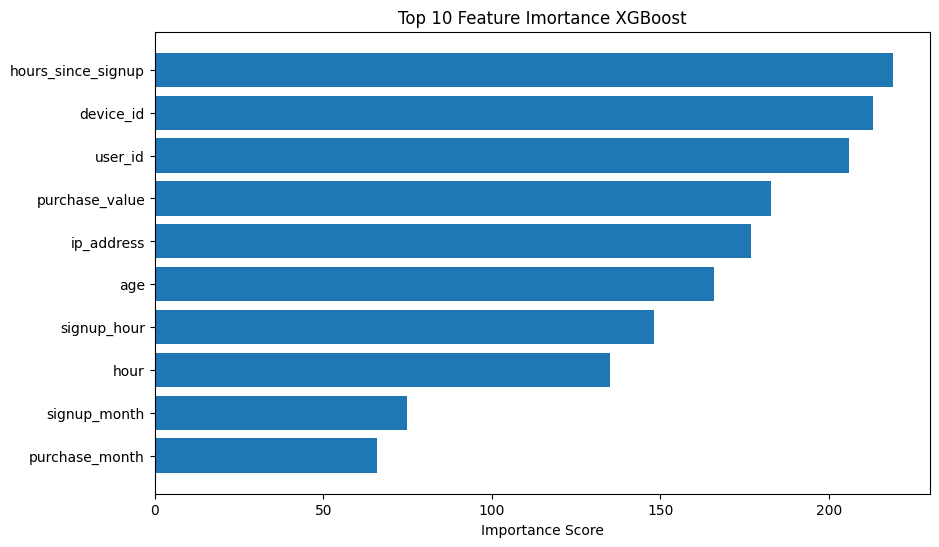

In [16]:
importance = xgb_model.get_booster().get_score(importance_type='weight')
importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'][:10][::-1], importance_df['importance'][:10][::-1])
plt.title("Top 10 Feature Imortance XGBoost")
plt.xlabel("Importance Score")
plt.show()

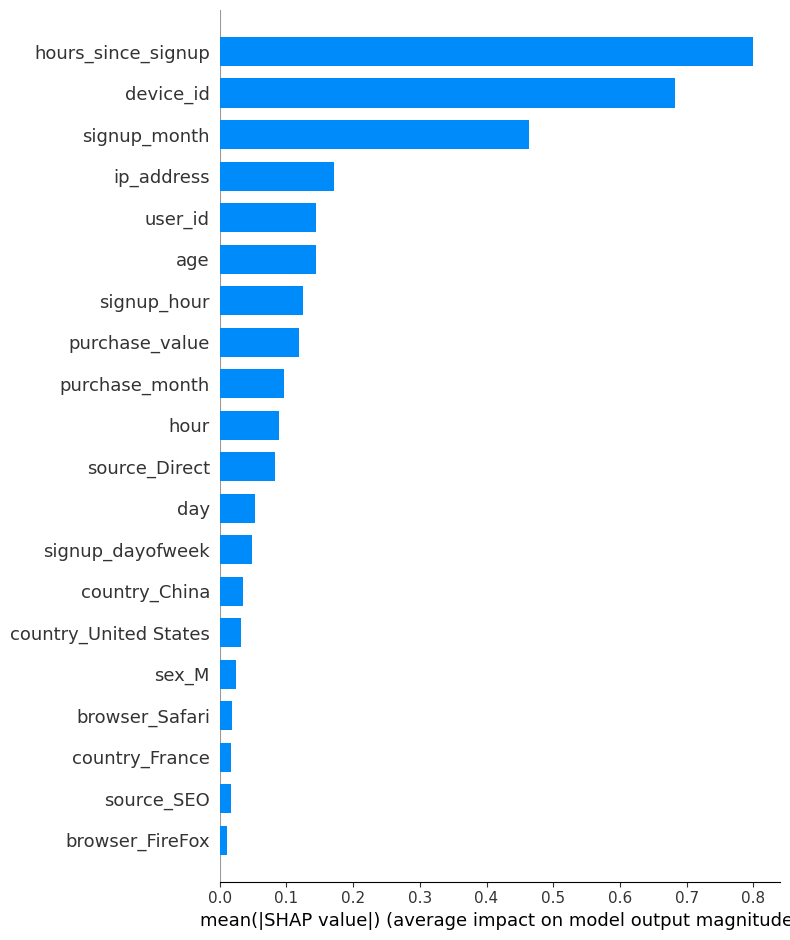

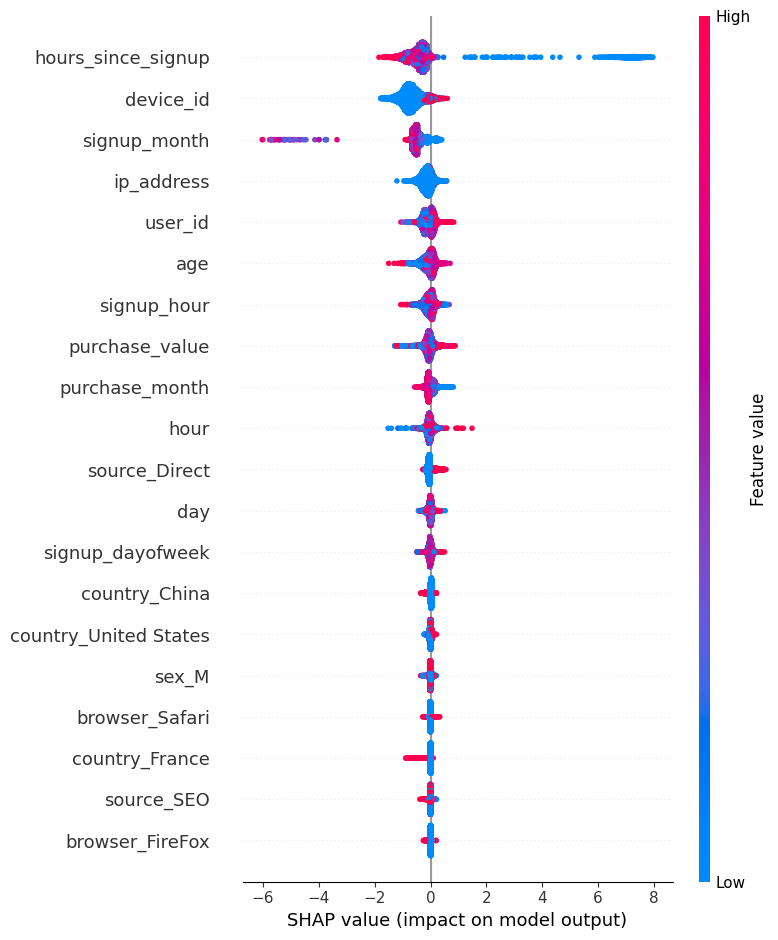

In [17]:


explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar')
shap.summary_plot(shap_values, X_test)


In [18]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])

In [20]:
import numpy as np
y_pred_proba = xgb_model.predict_proba(X_test)[:,1]
y_pred = (y_pred_proba >= 0.5).astype(int)

In [21]:
tp_idx = np.where((y_test == 1) & (y_pred == 1))[0]
fp_idx = np.where((y_test == 0) & (y_pred == 1))[0]
fn_idx = np.where((y_test == 1) & (y_pred == 0))[0]

In [22]:
tp_sample = tp_idx[0]
fp_sample = fp_idx[0]
fn_sample = fn_idx[0]

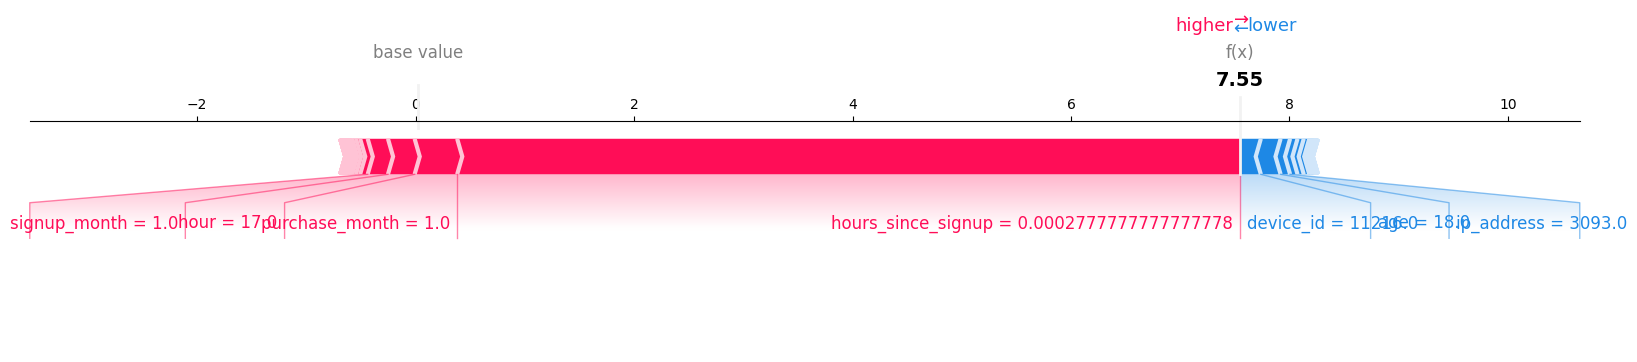

In [23]:
shap.force_plot(
    explainer.expected_value,
    shap_values[tp_sample],
    X_test.iloc[tp_sample],
    matplotlib=True
)

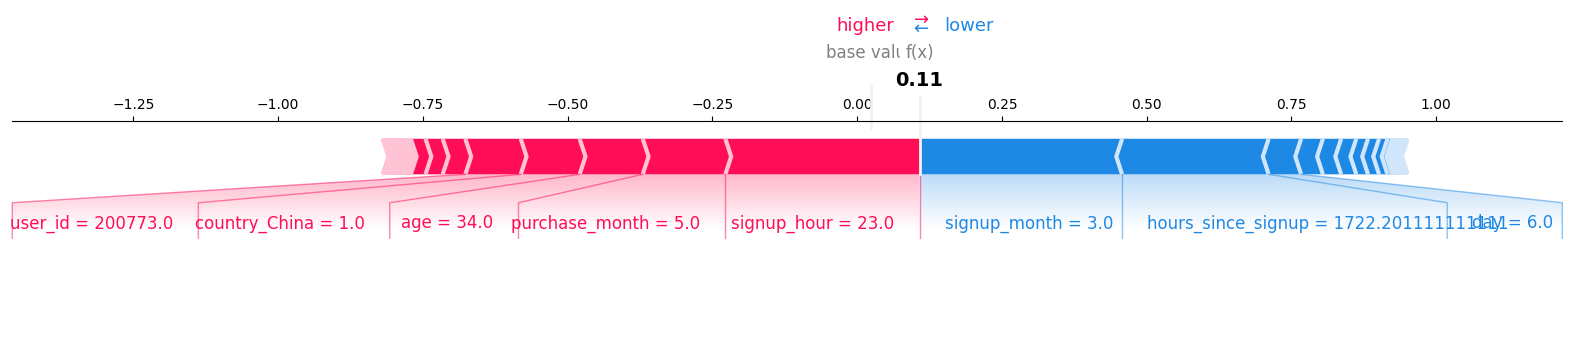

In [24]:
shap.force_plot(
    explainer.expected_value,
    shap_values[fp_sample],
    X_test.iloc[fp_sample],
    matplotlib=True
)

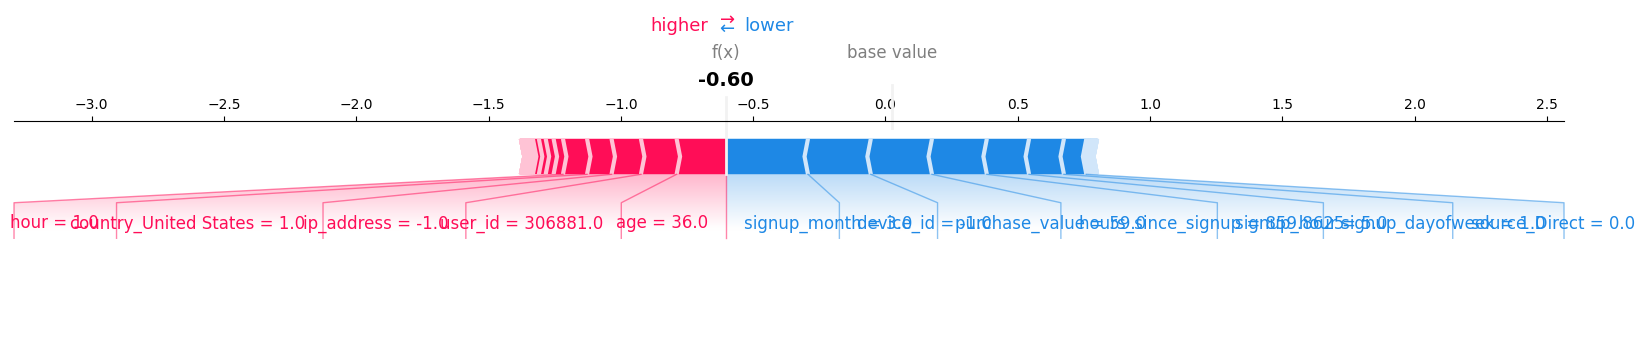

In [25]:
shap.force_plot(
    explainer.expected_value,
    shap_values[fn_sample],
    X_test.iloc[fn_sample],
    matplotlib=True
)

In [27]:
y_test.iloc[tp_sample], y_pred_proba[tp_sample]

(1, 0.9994722)

In [28]:
y_test.iloc[fp_sample], y_pred_proba[fp_sample]

(0, 0.52689064)

In [ ]:
y_test.iloc[fn_sample], y_pred_proba[fn_sample]

(1, 0.35391352)